# Sentiment Analysis — Random Forest baseline (TF-IDF)

A classic ML comparison point against the pretrained transformer in `01_baseline.ipynb`. Unlike the transformer, this one is actually *trained* here (TF-IDF + RandomForest).

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

df = pd.read_csv('../../datasets/clean_reviews.csv')
from sys import path; path.append('../..')
from src.sentiment.classifier import rating_to_sentiment
df['sentiment'] = df['star_rating'].apply(rating_to_sentiment)

## Train/test split
Stratified so all three classes are represented proportionally in both sets.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review_text'].astype(str), df['sentiment'],
    test_size=0.2, random_state=42, stratify=df['sentiment']
)

## TF-IDF vectorization

In [3]:
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print(X_train_vec.shape)

(37500, 20000)


## Train Random Forest
Using `class_weight='balanced'` since neutral (3-star) reviews are typically underrepresented.

In [4]:
clf = RandomForestClassifier(
    n_estimators=300, max_depth=None, random_state=42,
    n_jobs=-1, class_weight='balanced'
)
clf.fit(X_train_vec, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluate

In [5]:
preds = clf.predict(X_test_vec)
labels = ['negative', 'neutral', 'positive']
print(classification_report(y_test, preds, labels=labels))

              precision    recall  f1-score   support

    negative       0.84      0.10      0.18       368
     neutral       0.23      0.02      0.03       411
    positive       0.92      1.00      0.96      8597

    accuracy                           0.92      9376
   macro avg       0.66      0.37      0.39      9376
weighted avg       0.89      0.92      0.89      9376



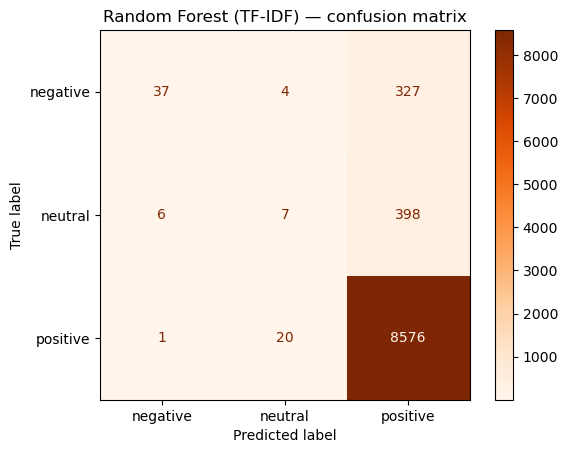

In [6]:
cm = confusion_matrix(y_test, preds, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Oranges')
plt.title('Random Forest (TF-IDF) — confusion matrix')
plt.show()

## Compare to the pretrained transformer
Load `01_baseline.ipynb`'s saved predictions and compare F1 scores side by side.

In [7]:
baseline = pd.read_csv('../../datasets/baseline_predictions.csv')
from sklearn.metrics import f1_score

rf_f1 = f1_score(y_test, preds, labels=labels, average='macro')
transformer_f1 = f1_score(baseline['true_sentiment'], baseline['predicted_sentiment'], labels=labels, average='macro')

print(f'Random Forest macro F1:  {rf_f1:.3f}')
print(f'Transformer macro F1:    {transformer_f1:.3f}')

Random Forest macro F1:  0.390
Transformer macro F1:    0.517


## Decision
If the Random Forest is competitive (or better) and much faster/cheaper to run, it may be worth using in production instead of the transformer — update `MODEL_NAME`/loader in `src/sentiment/classifier.py` accordingly. Otherwise, stick with the pretrained transformer.

If you decide to ship the Random Forest, persist it:

In [8]:
# joblib.dump(clf, '../../models/A_sentiment_analysis/random_forest.pkl')
# joblib.dump(vectorizer, '../../models/A_sentiment_analysis/tfidf_vectorizer.pkl')